In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist


In [3]:
X = np.array([
    [1, 2], [2, 2], [2, 3], [3, 3], [3, 4],
    [8, 8], [9, 8], [8, 9],
    [20, 20]   # Outlier
])

k = 2  # number of nearest neighbors

In [5]:
dist_matrix = cdist(X, X)

# Step 2: Get k-nearest neighbors
neighbors = []
for i in range(len(X)):
    sorted_idx = np.argsort(dist_matrix[i])
    neighbors.append(sorted_idx[1:k+1])  # exclude itself

neighbors = np.array(neighbors)

In [7]:
reverse_neighbors = []
for i in range(len(X)):
    rev = []
    for j in range(len(X)):
        if i in neighbors[j]:
            rev.append(j)
    reverse_neighbors.append(rev)


In [9]:
density = []
for i in range(len(X)):
    dists = dist_matrix[i][neighbors[i]]
    avg_dist = np.mean(dists)
    density.append(1 / (avg_dist + 1e-5))  # avoid division by zero

density = np.array(density)

In [11]:
inflo_scores = []

for i in range(len(X)):
    # Union of neighbors and reverse neighbors
    influence_set = set(neighbors[i]) | set(reverse_neighbors[i])

    if len(influence_set) == 0:
        inflo_scores.append(0)
        continue

    neighbor_density = np.mean([density[j] for j in influence_set])
    score = neighbor_density / density[i]
    inflo_scores.append(score)

inflo_scores = np.array(inflo_scores)

In [13]:
threshold = np.percentile(inflo_scores, 90)
outliers = inflo_scores > threshold

In [15]:
print("INFLO Scores:", inflo_scores)
print("Outliers:\n", X[outliers])

INFLO Scores: [ 1.20710471  0.91421427  0.91421427  0.91421427  1.20710471  0.82842855
  0.76041909  0.76041909 13.48571311]
Outliers:
 [[20 20]]


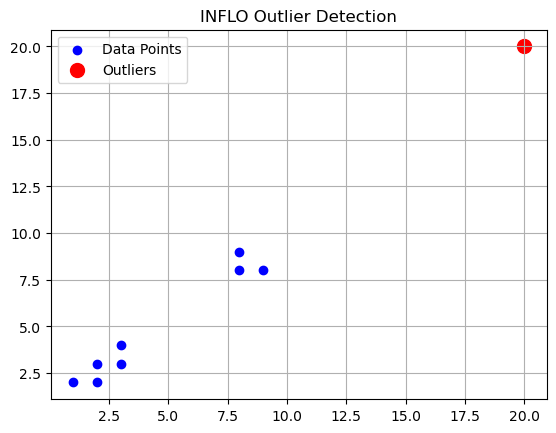

In [17]:
plt.scatter(X[:, 0], X[:, 1], color='blue', label='Data Points')

if np.any(outliers):
    plt.scatter(X[outliers][:, 0], X[outliers][:, 1],
                color='red', s=100, label='Outliers')

plt.title("INFLO Outlier Detection")
plt.legend()
plt.grid()
plt.show()